
# Construyendo un Perceptrón desde Cero
**Especialización en Ciencia de Datos e Inteligencia Artificial - UdeMedellín**

¡Manos a la obra! Antes de usar herramientas avanzadas como Keras, vamos a construir la red neuronal más simple posible: **El Perceptrón**.

## 1. El Problema de Negocio: Aprobación de Créditos
Imagina que trabajamos en un banco y queremos un modelo que decida automáticamente si aprobamos o rechazamos un préstamo basándonos en dos variables históricas de nuestros clientes:
* **$x_1$:** Nivel de Ingresos (Escalado).
* **$x_2$:** Historial Crediticio (Escalado).

Generaremos datos simulados de clientes del pasado.
* Los clientes en **amarillo (+1)** pagaron bien (Crédito Aprobado).
* Los clientes en **morado (-1)** no pagaron (Crédito Rechazado).


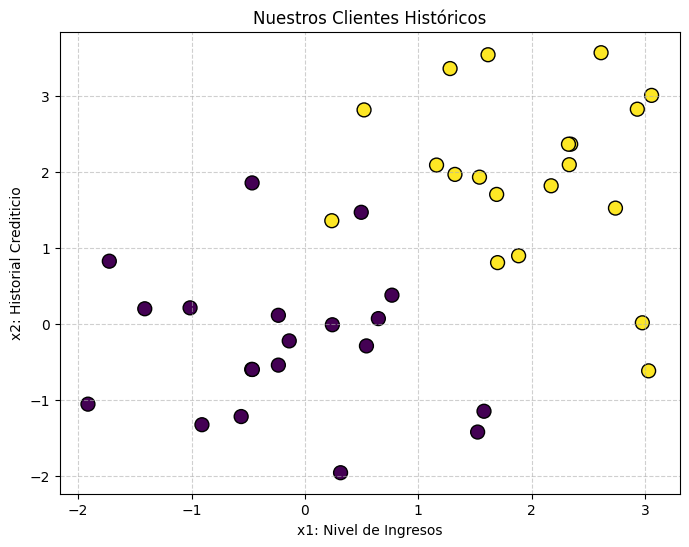

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERACIÓN DE DATOS FICTICIOS
np.random.seed(42) # Para que siempre nos salgan los mismos datos aleatorios

# Grupo 1: Clientes que NO pagaron (Rechazados, etiqueta -1)
# Tienen ingresos e historial crediticio más bajos en promedio
ingresos_rechazados = np.random.randn(20)
historial_rechazados = np.random.randn(20)
etiquetas_rechazados = -1 * np.ones(20)

# Grupo 2: Clientes que SÍ pagaron (Aprobados, etiqueta +1)
# Tienen ingresos e historial más altos (le sumamos 2.0 para separarlos un poco)
ingresos_aprobados = np.random.randn(20) + 2.0
historial_aprobados = np.random.randn(20) + 2.0
etiquetas_aprobados = np.ones(20)

# Juntamos todos los clientes en una sola lista
x1_ingresos = np.concatenate((ingresos_rechazados, ingresos_aprobados))
x2_historial = np.concatenate((historial_rechazados, historial_aprobados))
y_etiquetas = np.concatenate((etiquetas_rechazados, etiquetas_aprobados))
total_clientes = len(y_etiquetas)

# Visualizamos nuestro problema
plt.figure(figsize=(8,6))
plt.scatter(x1_ingresos, x2_historial, c=y_etiquetas, cmap='viridis', s=100, edgecolors='k')
plt.title("Nuestros Clientes Históricos")
plt.xlabel("x1: Nivel de Ingresos")
plt.ylabel("x2: Historial Crediticio")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 2. La Neurona "Ignorante" (Sin Entrenar)
Nuestro modelo necesita trazar una línea que separe a los clientes buenos de los malos. Esta línea se define matemáticamente por los **pesos ($w_1, w_2$)** y el **sesgo ($b$)**.
$$z = b + (w_1 \cdot x_1) + (w_2 \cdot x_2)$$

La función de activación evaluará $z$: si es mayor a 0, aprueba el crédito (+1); si es menor, lo rechaza (-1).


Vamos a crear la neurona y asignarle pesos totalmente aleatorios a ver qué tal lo hace.

Pesos iniciales aleatorios -> Sesgo(b): -0.03, w1: -1.17, w2: 1.14


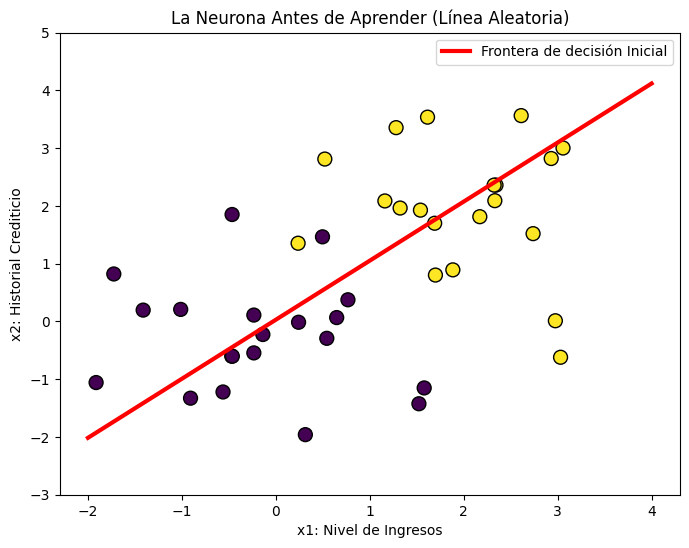

In [ ]:
# Definimos la función matemática de nuestra neurona (Sin matrices complejas)
def perceptron(ingreso, historial, b, w1, w2):
    # Suma ponderada
    z = b + (w1 * ingreso) + (w2 * historial)
    # Función de activación (Signo: devuelve +1 si z>0, y -1 si z<0)
    return np.sign(z)

# Inventamos pesos aleatorios iniciales (La neurona nace sin saber nada)
b = np.random.randn() # Sesgo
w1 = np.random.randn() # Peso para el ingreso
w2 = np.random.randn() # Peso para el historial

print(f"Pesos iniciales aleatorios -> Sesgo(b): {b:.2f}, w1: {w1:.2f}, w2: {w2:.2f}")

# Dibujamos cómo corta el espacio esta neurona "ignorante"
plt.figure(figsize=(8,6))
plt.scatter(x1_ingresos, x2_historial, c=y_etiquetas, cmap='viridis', s=100, edgecolors='k')

# Matemáticas para dibujar la línea de decisión: x2 = (-b/w2) - (w1/w2)*x1
linea_x = np.array([-2, 4])
linea_y = -(b/w2) - (w1/w2)*linea_x
plt.plot(linea_x, linea_y, color='red', linewidth=3, label='Frontera de decisión Inicial')

plt.title("La Neurona Antes de Aprender (Línea Aleatoria)")
plt.xlabel("x1: Nivel de Ingresos")
plt.ylabel("x2: Historial Crediticio")
plt.legend()
plt.ylim(-3, 5) # Fijamos los límites para ver bien
plt.show()

## 3. El Entrenamiento: Descenso del Gradiente
Como vimos, la línea roja aleatoria es un desastre: aprobaría créditos a quienes no pagan y rechazaría a los buenos clientes.

Para que aprenda, usaremos el **Descenso del Gradiente**. Por cada cliente histórico:
1. La neurona hace una **predicción**.
2. Calculamos el **error** (lo que esperábamos menos lo que predijo).
3. Calculamos la **derivada** (hacia dónde está el valle del error).
4. **Actualizamos los pesos** dando un pequeño paso definido por la Tasa de Aprendizaje ($\alpha$).



In [ ]:
alpha = 0.05 # Tasa de aprendizaje (qué tan grandes son los pasos al aprender)
epocas = 50  # Cuántas veces repasaremos la lista de clientes completa

# Bucle de entrenamiento (Épocas)
for epoca in range(epocas):

    # Acumuladores para calcular el error general y las derivadas
    derivada_b = 0
    derivada_w1 = 0
    derivada_w2 = 0

    # Repasamos cliente por cliente (Bucle explícito, sin álgebra lineal densa)
    for i in range(total_clientes):
        # 1. Extraemos los datos del cliente actual
        ingreso_actual = x1_ingresos[i]
        historial_actual = x2_historial[i]
        etiqueta_real = y_etiquetas[i]

        # 2. La neurona hace su predicción
        prediccion = perceptron(ingreso_actual, historial_actual, b, w1, w2)

        # 3. Calculamos la diferencia (Error)
        error = etiqueta_real - prediccion

        # 4. Acumulamos las derivadas (la dirección en la que debemos corregir)
        derivada_b += error
        derivada_w1 += error * ingreso_actual
        derivada_w2 += error * historial_actual

    # 5. Promediamos las derivadas dividiendo por el total de clientes
    derivada_b = -(2 * derivada_b) / total_clientes
    derivada_w1 = -(2 * derivada_w1) / total_clientes
    derivada_w2 = -(2 * derivada_w2) / total_clientes

    # 6. ACTUALIZACIÓN DE PESOS (El Descenso del Gradiente en acción)
    b = b - (alpha * derivada_b)
    w1 = w1 - (alpha * derivada_w1)
    w2 = w2 - (alpha * derivada_w2)

print("¡Entrenamiento finalizado!")
print(f"Pesos finales óptimos -> Sesgo(b): {b:.2f}, w1: {w1:.2f}, w2: {w2:.2f}")

¡Entrenamiento finalizado!
Pesos finales óptimos -> Sesgo(b): -0.54, w1: 0.27, w2: 0.34


### 💻 Celda de Código 4 (Python)

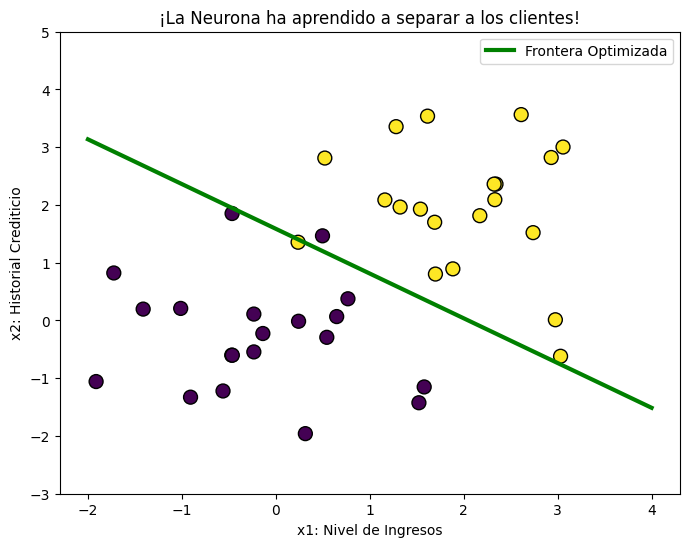

In [ ]:
# 4. VISUALIZACIÓN FINAL
plt.figure(figsize=(8,6))
plt.scatter(x1_ingresos, x2_historial, c=y_etiquetas, cmap='viridis', s=100, edgecolors='k')

# Dibujamos la nueva línea de decisión optimizada
linea_y_optimizada = -(b/w2) - (w1/w2)*linea_x
plt.plot(linea_x, linea_y_optimizada, color='green', linewidth=3, label='Frontera Optimizada')

plt.title("¡La Neurona ha aprendido a separar a los clientes!")
plt.xlabel("x1: Nivel de Ingresos")
plt.ylabel("x2: Historial Crediticio")
plt.legend()
plt.ylim(-3, 5)
plt.show()